In [1]:
import os
os.getcwd()

'/Users/gpiren/Library/CloudStorage/Dropbox/Mac (2)/Desktop/Projects/Finance/TRY Contagion'

### Research Question: 

How do Turkish Lira (TRY) crisis events create contagion effects across emerging market
currencies, Turkish equities (BIST 100), and European financial institutions with Turkey exposure?

This project addresses a critical risk management concern for global investors. Currency crises in one emerging market can trigger cascading effects across interconnected financial systems. Understanding these transmission channels is essential for portfolio diversification, hedging strategies, and systemic risk assessment.

The Turkish Lira has recently experienced significant volatility (2018 crisis, 2021-2023 depreciation), making it an ideal case study for analyzing financial contagion. 

This research has direct applications in: 

- Risk management for EM-exposed portfolios
- Cross-asset hedging strategies
- Early warning systems for contagion events
- Understanding interconnectedness in global financial markets.

### Some key concepts for better understanding of the subject:

- Financial Contagion: The spread of market disturbances from one country to others through trade linkages, financial linkages, or investor behavior
- Correlation vs. Causation: Distinguishing whether assets move together due to common shocks or actual transmission effects
- Systemic Risk: The risk that failure in one part of the system spreads to the entire system
- Event Study: Analyzing asset price movements around specific events (TRY crashes) to isolate crisis impacts
- Rolling Correlations: Time-varying correlation measures that capture changing market relationships during crises

### Things to keep in mind

* Define crisis/regime rules before testing
* Control for volatility (don’t mistake correlation for contagion)
* Avoid look-ahead and survivorship bias
* Test statistical significance, not just visuals
* Check robustness with alternative specifications
* Ensure economic interpretation makes sense
* Validate results out-of-sample
* Compare against a simple benchmark


### Datasets to use

- USD/TRY exchange rate (daily data) – Used to identify crisis events and measure the magnitude of Turkish Lira shocks.

- BIST 100 index prices (daily data) – Captures the response of Turkish equity markets to currency crises.

- Emerging market FX rates (e.g., BRL, ZAR, MXN) – Allows measurement of spillover effects to other emerging market currencies.

- European bank stock prices (banks with Turkey exposure) – Measures financial contagion through cross-border banking linkages.

- Global risk indicator (e.g., VIX) – Controls for global risk aversion to distinguish local contagion from global shocks.

   - The VIX (CBOE Volatility Index) is a market index that measures expected stock market volatility over the next 30 days, and it is widely used as a gauge of investor fear and global risk sentiment. It does not equal to investor fear, it only reflects a sentiment which usually leads to investor fear.

- Risk-free rate (short-term interest rate) – Required for excess return calculations and statistical testing.

In [6]:
import yfinance as yf
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

In [7]:
tickers = [
    "USDTRY=X",
    "XU100.IS",
    "^VIX",
    "USDZAR=X",
    "USDMXN=X",
    "USDBRL=X"
]

# The auto_adjust parameter in yf.download, when set to True, automatically adjusts the price data (such as Close, Open, High, Low)
# for corporate actions like splits and dividends. This means 'Close' prices will reflect total returns rather than just raw prices, 
# ensuring consistent analysis especially for equities or indices where such events may occur.
data = yf.download(
    tickers,
    start="2018-01-01",
    end="2025-01-01",
    interval="1d",
    auto_adjust=True   # Prices adjusted for splits and dividends
)


[*********************100%***********************]  6 of 6 completed


In [8]:
clean_data = data["Close"].copy().dropna(how="all")

In [9]:
clean_data.head()

Ticker,USDBRL=X,USDMXN=X,USDTRY=X,USDZAR=X,XU100.IS,^VIX
Date,,,,,,
2018-01-01,3.3076,19.650850,3.79490,12.31999,NaN,NaN
2018-01-02,3.3110,19.497400,3.79110,12.38700,1175.235718,9.77
2018-01-03,3.2578,19.351101,3.76560,12.43562,1160.515869,9.15
2018-01-04,3.2355,19.306971,3.78060,12.36100,1154.905884,9.22
2018-01-05,3.2331,19.174000,3.75027,12.28720,1166.372803,9.22


In [ ]:
# Creating a separate table for returns
# We calculate daily returns because returns (rather than prices) are more suitable for financial analysis:
# - Returns standardize changes across assets with different price levels, enabling direct comparison.
# - Statistical properties such as mean, standard deviation, and correlation are more meaningful when computed on returns.
# - Most financial models and risk/contagion analyses are built on return series, not raw prices.
#
# Calculation:
# The daily return for each asset is computed as the percentage change from the previous day's close:
#    return_t = (price_t - price_{t-1}) / price_{t-1}

returns = clean_data.pct_change(fill_method=None)

In [11]:
# We drop missing values in our returns table and just take a look

returns = returns.dropna()
returns.head()

Ticker,USDBRL=X,USDMXN=X,USDTRY=X,USDZAR=X,XU100.IS,^VIX
Date,,,,,,
2018-01-03,-0.016068,-0.007504,-0.006726,0.003925,-0.012525,-0.063460
2018-01-04,-0.006845,-0.002281,0.003983,-0.006001,-0.004834,0.007650
2018-01-05,-0.000742,-0.006887,-0.008023,-0.005970,0.009929,0.000000
2018-01-08,-0.002010,0.000945,-0.004778,0.000679,-0.002858,0.032538
2018-01-09,0.003843,0.002739,0.003095,0.006251,-0.011020,0.058823


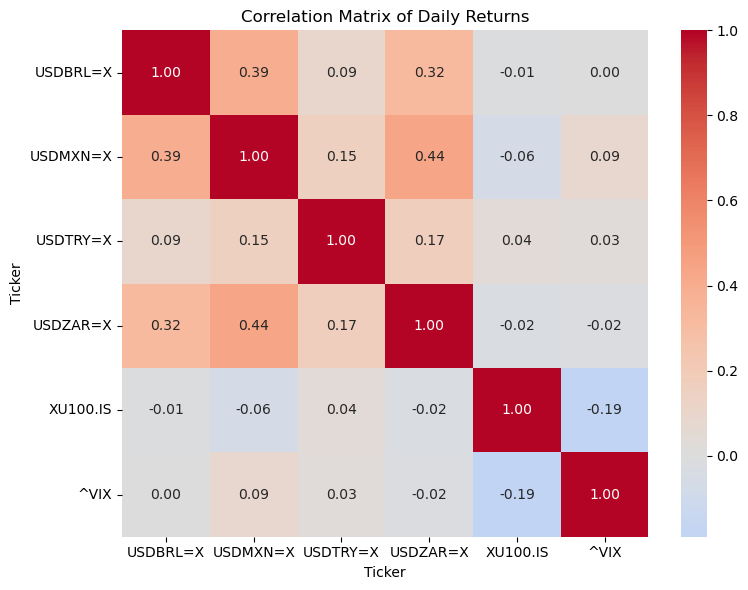

In [ ]:
# Let's compute the correlation matrix of returns
plt.figure(figsize=(8,6))
sns.heatmap(returns.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix of Daily Returns")
# The resulting correlation heatmap illustrates how closely the daily returns of the selected assets move together.
# For example:
# - Higher correlations (closer to 1, warm colors) between pairs suggest strong co-movement—meaning, when one asset's return increases, the other's tends to as well.
# - Lower or negative correlations (closer to 0 or negative values, cooler colors) indicate weak or inverse relationships—one asset's gains may correspond to another's losses, or little connection at all.

# Key implications in the context of contagion:

# - If the Turkish Lira (TRY) has low correlations with other EM currencies in normal periods but these increase substantially during crises, it may signal financial contagion.
# - EM currencies (like BRL, MXN, ZAR) that show consistently moderate to high correlations might naturally move together due to global risk sentiment.
# - The behavior of the BIST 100 equity index and the VIX (global risk index) in relation to FX assets provides insight into how Turkish financial markets react to both local shocks and international volatility.
plt.tight_layout()
plt.show()

### Daily returns - correlation

#### Correlation Matrix – Key Takeaways

- EM currencies (BRL, MXN, ZAR) show moderate positive correlations (0.32–0.44), indicating normal interdependence within Emerging Market (EM) FXs.
- TRY exhibits relatively low correlation with other EM currencies (0.09–0.17), suggesting limited baseline co-movement
- BIST 100 has near-zero correlation with EM FX but negative correlation with VIX (-0.19), indicating sensitivity to global risk sentiment.
- VIX behaves as expected: slightly positive with EM FX and negative with equities.

#### Implications for Contagion Analysis

- Since TRY correlations are low in normal periods (with other EM currencies), any sharp increase during crisis windows would provide stronger evidence of true contagion.
- EM FX already co-move structurally, so increases must be statistically tested to distinguish contagion from normal clustering.
- VIX should be controlled for to separate Turkey-specific spillovers from global risk-off episodes.


In [13]:
# detect crisis days using a volatility-adjusted threshold (2 std devs of a 30-day rolling window)
rolling_std = returns["USDTRY=X"].rolling(window=30).std()
crisis_days = returns[returns["USDTRY=X"] >= 2 * rolling_std]
crisis_days.head()

Ticker,USDBRL=X,USDMXN=X,USDTRY=X,USDZAR=X,XU100.IS,^VIX
Date,,,,,,
2018-03-23,0.012650,-0.008774,0.016657,0.004646,-0.004334,0.065553
2018-04-06,0.004177,0.006586,0.010077,0.010646,-0.001828,0.134636
2018-05-03,0.012407,0.008202,0.017941,0.002314,-0.017346,-0.004383
2018-05-09,0.003578,0.006358,0.019501,0.003787,0.014259,-0.087695
2018-05-14,0.015044,0.005484,0.017947,-0.004982,0.014903,0.022134


In [14]:
# extract ±5 trading day windows around each TRY crisis day
event_windows = []

for date in crisis_days.index:
    loc = returns.index.get_loc(date)
    window = returns.iloc[max(0, loc - 5) : loc + 6]  # 5 before, day itself, 5 after
    event_windows.append(window)

event_windows = pd.concat(event_windows)
event_windows = event_windows[~event_windows.index.duplicated(keep='first')]

event_windows.head()

Ticker,USDBRL=X,USDMXN=X,USDTRY=X,USDZAR=X,XU100.IS,^VIX
Date,,,,,,
2018-03-16,0.007243,-0.000680,0.003412,0.011426,0.000126,-0.047619
2018-03-19,-0.000609,0.001216,0.006359,0.006697,-0.015066,0.203797
2018-03-20,0.001219,0.002492,0.006378,0.002615,0.008501,-0.043112
2018-03-21,0.007491,-0.016024,-0.002825,-0.004872,0.010474,-0.018681
2018-03-22,-0.010880,0.012492,-0.005946,-0.010639,-0.004598,0.306831


In [15]:
# Now comparing correlations inside these windows vs normal periods

crisis_corr = event_windows.corr()
crisis_corr

Ticker,USDBRL=X,USDMXN=X,USDTRY=X,USDZAR=X,XU100.IS,^VIX
Ticker,,,,,,
USDBRL=X,1.000000,0.372964,0.100787,0.230234,-0.005318,0.036233
USDMXN=X,0.372964,1.000000,0.153280,0.355187,-0.087340,0.064298
USDTRY=X,0.100787,0.153280,1.000000,0.140422,0.074683,0.073837
USDZAR=X,0.230234,0.355187,0.140422,1.000000,-0.022211,-0.054328
XU100.IS,-0.005318,-0.087340,0.074683,-0.022211,1.000000,-0.174413
^VIX,0.036233,0.064298,0.073837,-0.054328,-0.174413,1.000000


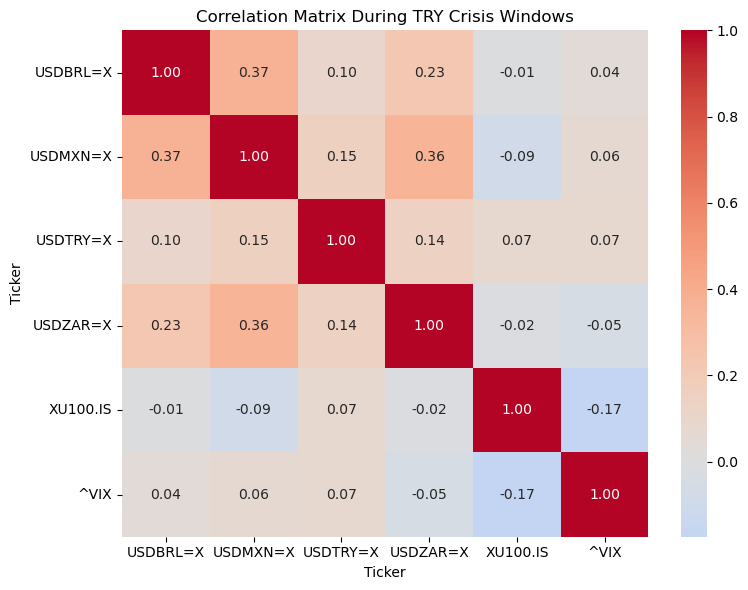

In [16]:
# to visualize it

plt.figure(figsize=(8,6))
sns.heatmap(crisis_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix During TRY Crisis Windows")
plt.tight_layout()
plt.show()

### Correlations around the crisis days

Here we are looking at correlations only within the ±5 trading day windows around each TRY crisis day (days where TRY depreciation exceeded 2 standard deviations of its 30-day rolling volatility), covering the entire 2018–2025 period.

#### Key takeaways from correlation matrix

- MXN (0.15) and ZAR (0.14) show the strongest co-movement with TRY during crisis windows, though both are weak in absolute terms. Neither provides strong standalone evidence of contagion.
- BRL (0.10) is marginally lower, broadly in line with MXN and ZAR. The three EM currencies cluster together, suggesting whatever spillover exists is diffuse rather than country-specific.
- BIST (0.07) shows near-zero correlation with TRY during crisis windows, which is counterintuitive but consistent with the earlier full-period matrix. The domestic equity market does not appear to move with the currency during shocks at this frequency.
- VIX (0.07) is essentially flat against TRY during crisis windows. This is a methodologically meaningful insighy: by adjusting for prevailing volatility, we are filtering out some of the global risk-off episodes that were previously contaminating the crisis sample. The remaining events are more Turkey-specific, and VIX barely reacts to them.

The overall picture is more muted than the fixed-threshold version that I tried with %3 earlier. 

This is expected: the volatility-adjusted threshold is stricter about what counts as a genuine shock, so the crisis windows are cleaner but the average co-movement across assets is lower. The t-tests in the next step will tell us whether even these modest differences are statistically meaningful.

### Computing the rolling correlations

We will now run t-tests correlations to check if the differences are statistically significant.

For each asset pair (TRY vs BRL, MXN, ZAR, BIST), we calculate a correlation using only the past 30 days of data, then slide that window forward one day at a time. 

This gives us a daily time series of how the correlation between TRY and each asset evolves over time, instead of one static number for the whole period. 

This way we can actually see correlations spiking during crisis periods and dropping during calm periods, which is meaningful for a contagion study.

In [19]:
# The first 29 rows of the table will be all NaNs. That's because this table is for rolling correlations of a month (30 days)

rolling_corr = {}

pairs = ["USDBRL=X", "USDMXN=X", "USDZAR=X", "XU100.IS"]

for pair in pairs:
    rolling_corr[pair] = returns["USDTRY=X"].rolling(window=30).corr(returns[pair])

rolling_corr_df = pd.DataFrame(rolling_corr)
rolling_corr_df.head()

,USDBRL=X,USDMXN=X,USDZAR=X,XU100.IS
Date,,,,
2018-01-03,NaN,NaN,NaN,NaN
2018-01-04,NaN,NaN,NaN,NaN
2018-01-05,NaN,NaN,NaN,NaN
2018-01-08,NaN,NaN,NaN,NaN
2018-01-09,NaN,NaN,NaN,NaN


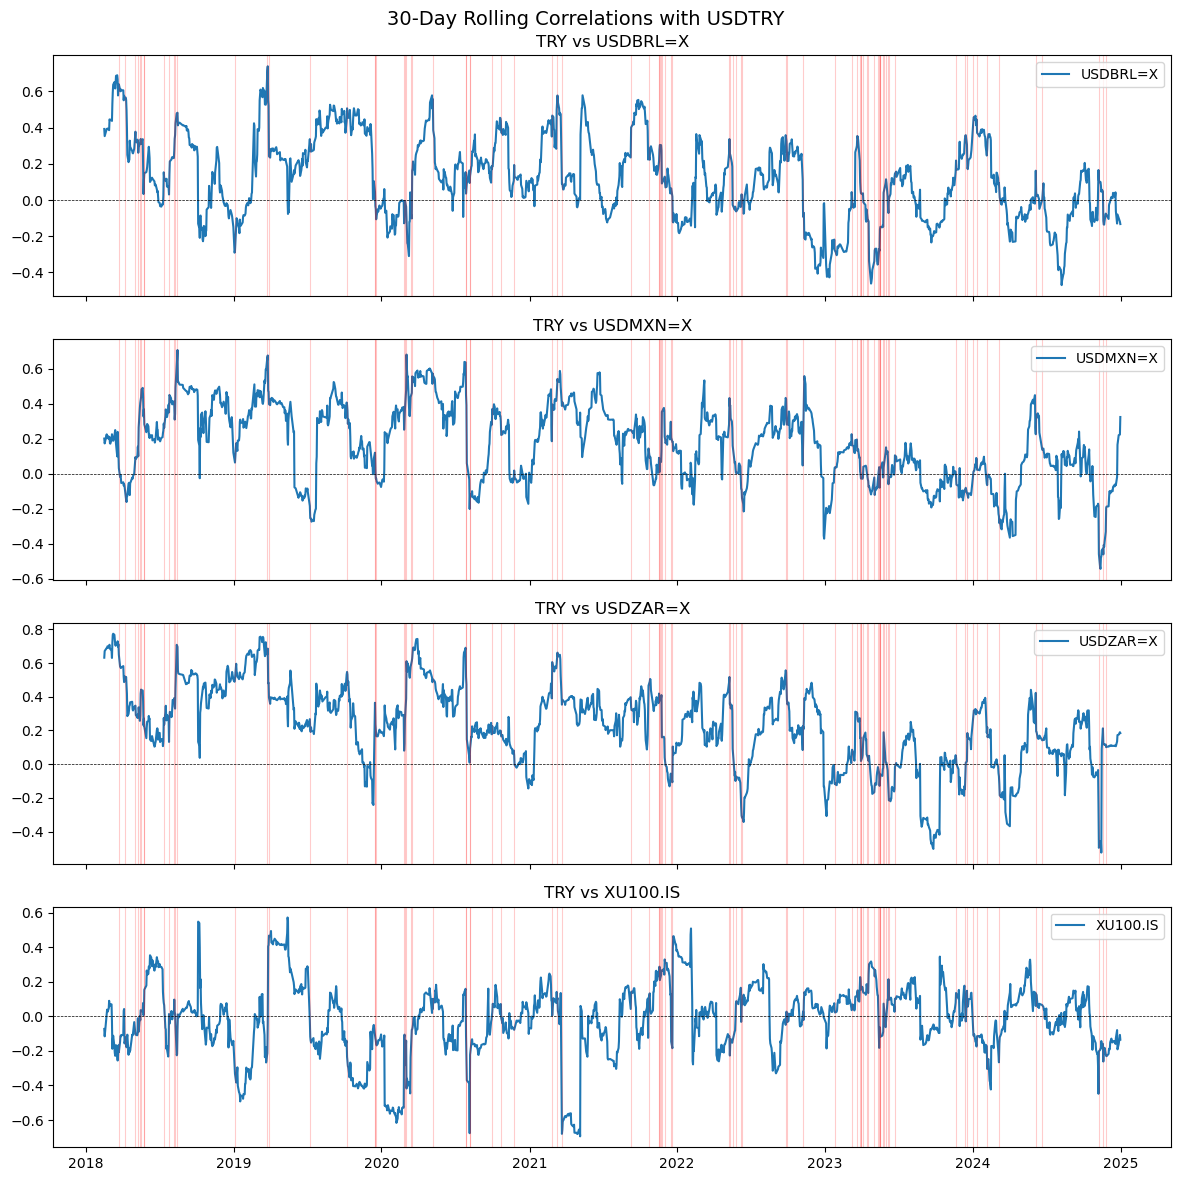

In [20]:
fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=True)

for ax, pair in zip(axes, pairs):
    ax.plot(rolling_corr_df.index, rolling_corr_df[pair], label=pair)
    for date in crisis_days.index:
        ax.axvline(x=date, color='red', alpha=0.2, linewidth=0.8)
    ax.axhline(y=0, color='black', linewidth=0.5, linestyle='--')
    ax.set_title(f"TRY vs {pair}")
    ax.legend()

plt.suptitle("30-Day Rolling Correlations with USDTRY", fontsize=14)
plt.tight_layout()
plt.show()

### Visualisations - rolling correlations around crises

Each line shows how the 30-day rolling correlation between TRY and that asset changes over time. The red vertical lines mark TRY crisis days identified by the volatility-adjusted threshold. Ideally we want to see the lines spike upward around those red lines to confirm contagion.

ZAR: strongest and most consistent co-movement with TRY, but the relationship has been fading since 2023.
MXN: showed a meaningful link in earlier years but has largely decoupled from TRY by the end of the sample.
BRL: no reliable signal in either direction across the full period.
BIST: the most volatile relationship of all, with no stable directional pattern relative to TRY.

The plots only show the direction and rough magnitude of rolling correlations over time. They say nothing about whether those correlations are statistically different from zero or from their values in normal periods. 

The red lines are now more densely clustered in certain periods, particularly 2018-2019 and 2023-2024, which reflects the volatility-adjusted threshold flagging shocks relative to already-elevated baseline volatility. Even so, there are no obvious systematic spikes in correlation around these lines across all four assets, reinforcing that contagion here is not a clean, immediate, or universal effect.

In [21]:
# creating a clean version by removing duplicate dates (handling overlaps)
event_windows_clean = event_windows[~event_windows.index.duplicated(keep='first')]

# sorting the index 
event_windows_clean = event_windows_clean.sort_index()

In [22]:
# Comparing rolling correlation values during crisis windows vs. normal periods 
# This is to check if the difference is statistically significant (p<0.05 = significant contagion).

normal_returns = returns[~returns.index.isin(event_windows_clean.index)]

for pair in pairs:
    crisis_vals = rolling_corr_df.loc[event_windows_clean.index, pair].dropna()
    normal_vals = rolling_corr_df.loc[normal_returns.index, pair].dropna()
    t_stat, p_val = stats.ttest_ind(crisis_vals, normal_vals)
    print(f"TRY vs {pair}: t={t_stat:.3f}, p={p_val:.3f}")

TRY vs USDBRL=X: t=4.511, p=0.000
TRY vs USDMXN=X: t=-2.854, p=0.004
TRY vs USDZAR=X: t=-1.043, p=0.297
TRY vs XU100.IS: t=1.173, p=0.241


### Key takeaways - Rolling correlations

Results are more nuanced under the volatility-adjusted threshold, and one finding runs counter to the contagion hypothesis.

- BRL (p=0.000): The strongest and most surprising result. Rolling correlations with TRY are significantly higher during crisis windows, meaning Brazil does become more sensitive to Turkish shocks during extreme events despite showing no stable baseline relationship.
- MXN (p=0.004): Significant, but the negative t-statistic means correlations with TRY are actually lower during crisis windows than in normal periods. This is the opposite of contagion — TRY shocks appear to decouple Mexico rather than pull it closer, possibly because volatility-adjusted crisis days are more Turkey-specific and less driven by global risk-off episodes that would affect both.
- ZAR (p=0.297): Not significant. Despite appearing structurally correlated with TRY in the plots, the relationship does not shift meaningfully during crisis periods, pointing to interdependence rather than contagion.
- BIST (p=0.241): Not significant. The domestic equity market shows no statistically meaningful regime change around TRY shocks at this frequency.

By filtering out global risk-off episodes, the volatility-adjusted approach isolates BRL as the one asset that genuinely responds to Turkey-specific shocks, while MXN's earlier significance is revealed to have been partly driven by common global factors.

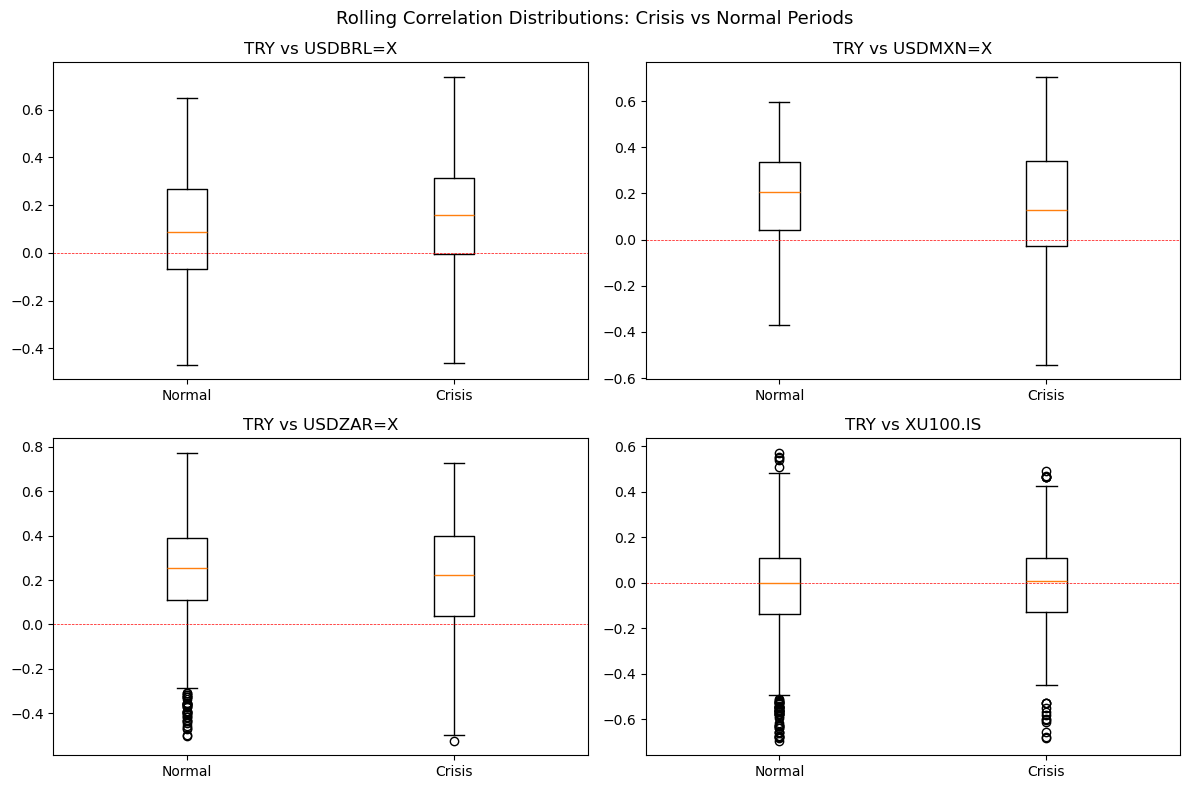

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, pair in zip(axes.flatten(), pairs):
    crisis_vals = rolling_corr_df.loc[event_windows_clean.index, pair].dropna()
    normal_vals = rolling_corr_df.loc[normal_returns.index, pair].dropna()
    ax.boxplot([normal_vals, crisis_vals], tick_labels=["Normal", "Crisis"])
    ax.set_title(f"TRY vs {pair}")
    ax.axhline(y=0, color='red', linewidth=0.5, linestyle='--')

plt.suptitle("Rolling Correlation Distributions: Crisis vs Normal Periods", fontsize=13)
plt.tight_layout()
plt.show()

### T-test results

- BRL (p=0.000): The strongest result. Rolling correlations with TRY are significantly higher during crisis windows, and the positive t-statistic confirms the direction. Brazil is usually decoupled from Turkey, but genuinely becomes more sensitive during Turkey-specific shocks, possibly reflecting investor behavior treating both as interchangeable EM risk proxies.

- MXN (p=0.004): Significant, but the negative t-statistic tells a different story. Correlations with TRY are actually lower during crisis windows than in normal periods. This is the opposite of contagion — TRY shocks appear to decouple Mexico rather than draw it closer, likely because the volatility-adjusted crisis days are more Turkey-specific and less contaminated by global risk-off episodes that would move both currencies together.

- ZAR (p=0.297): Not significant. The two distributions are nearly identical, confirming structural interdependence rather than crisis-driven contagion. ZAR and TRY co-move consistently regardless of regime.

- BIST (p=0.241): Not significant. The domestic equity market shows no meaningful distributional shift around TRY shock days at this frequency.

#### T-test visuals

- BRL: The Crisis box sits visibly higher than Normal, with a higher median and an upward shift in the overall distribution. This is fully consistent with the t-test (p=0.000, positive t-stat).

- MXN: Counterintuitively, the Normal box has a higher median than Crisis. The Crisis distribution shifts slightly downward, which is what drives the significant but negative t-statistic — correlations fall rather than rise during TRY shocks.

- ZAR: Both boxes are nearly identical in position and spread, with medians around 0.25 in both periods. The t-test non-result is clearly visible here. ZAR is structurally correlated with TRY independent of crisis regime.

- BIST: Both boxes are centered around zero with very similar spreads. The wide range in both periods reflects the high volatility seen in the rolling correlation plots, but there is no shift between regimes.

All four visuals are consistent with their t-test results. There are no contradictions.


### The Event Study 

We are now calculating cumulative abnormal returns (CAR) for each asset around TRY crisis days.

For each TRY crisis day, we calculate what each asset's return should have been on a normal day (the baseline), then compare it to what actually happened. 
The difference is the "abnormal return." We then sum these up across the ±5 day window to get the Cumulative Abnormal Return (CAR), which is essentially measuring how much each asset was pushed away from its normal behavior by the TRY shock.

This will help us move beyond correlation, correlation only tells us that assets move together, but CAR tells us the actual magnitude of the impact. 

In [24]:
# compute per-event baseline using t-120 to t-10 trading days before each crisis day
abnormal_returns_list = []

for date in crisis_days.index:
    loc = returns.index.get_loc(date)
    if loc < 120:  # skip events too early in the series
        continue
    pre_window = returns.iloc[loc - 120 : loc - 10][pairs]
    normal_mean = pre_window.mean()
    event_window = returns.iloc[max(0, loc - 5) : loc + 6][pairs]
    ar = event_window - normal_mean
    abnormal_returns_list.append(ar)

abnormal_returns = pd.concat(abnormal_returns_list)
abnormal_returns = abnormal_returns[~abnormal_returns.index.duplicated(keep='first')]

CAR = abnormal_returns.groupby(level=0).sum()
avg_CAR = CAR.mean()

print("Average Cumulative Abnormal Returns (per-event baseline, t-120 to t-10):")
print(avg_CAR)

Average Cumulative Abnormal Returns (per-event baseline, t-120 to t-10):
Ticker
USDBRL=X    0.000295
USDMXN=X    0.000252
USDZAR=X    0.000438
XU100.IS   -0.001208
dtype: float64


NOTE:

Each event uses its own baseline: the average daily return over the 110 trading days ending 10 days before the crisis, making the benchmark time-appropriate and free from contamination by nearby stress periods.

These are very small numbers in decimal return form. Multiplying by 100 to get percentages:

BIST (-0.12%): The largest abnormal movement, and negative. During TRY crisis windows, Turkish equities actually underperform their own recent baseline. 

FX Pairs: All three show small positive CARs, meaning the USD appreciated slightly against these currencies during TRY crisis windows. USDZAR (0.04%), USDMXN (0.03%), and USDBRL (0.03%) are nearly identical and very close to zero. The effect is real in direction but negligible in magnitude, suggesting that while these currencies do weaken slightly when TRY is under stress, the actual price impact is minimal.

The overall picture is consistent with the t-test findings: genuine but modest contagion footprint, concentrated in investor behavior rather than large directional price moves.

For each crisis event, we sum up the abnormal returns (actual minus per-event baseline) across the full ±5 day window to get one CAR per event, then run a t-test across all event CARs to check if they are significantly different from zero.

This will tell us whether each asset's abnormal returns during TRY crisis windows are statistically meaningful. Did TRY crises actually cause consistent deviations from normal behavior, or were the CARs we saw just random noise?

TRY vs USDBRL=X: t=1.230, p=0.222
TRY vs USDMXN=X: t=1.176, p=0.243
TRY vs USDZAR=X: t=1.456, p=0.149
TRY vs XU100.IS: t=-0.909, p=0.366


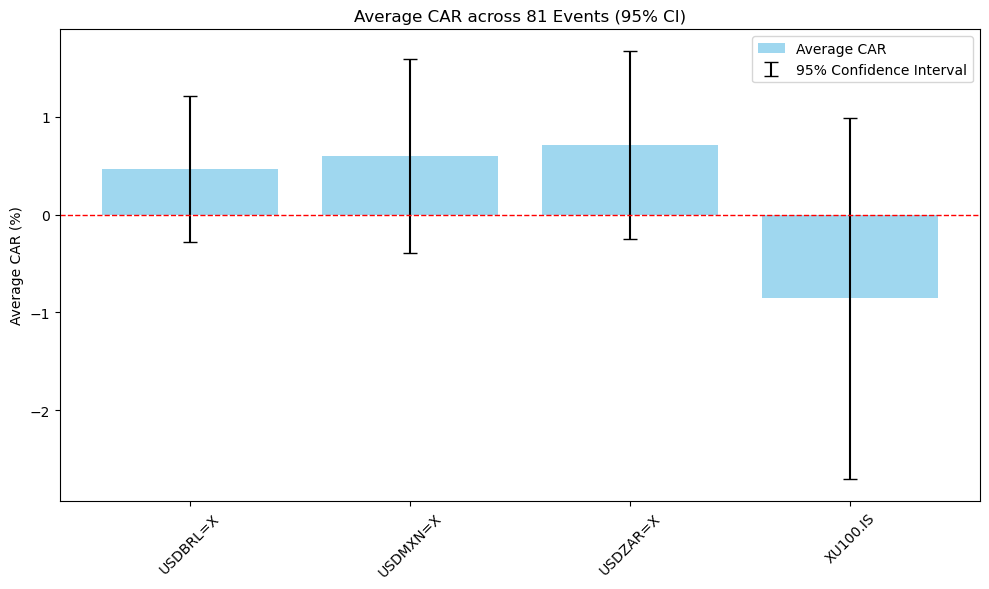

In [26]:
# compute one CAR per event and run t-test against zero
event_CARs = {}

for date in crisis_days.index:
    loc = returns.index.get_loc(date)
    if loc < 120:
        continue
    pre_window = returns.iloc[loc - 120 : loc - 10][pairs]
    normal_mean = pre_window.mean()
    event_window = returns.iloc[max(0, loc - 5) : loc + 6][pairs]
    ar = event_window - normal_mean
    event_CARs[date] = ar.sum()

CAR_df = pd.DataFrame(event_CARs).T  # rows = events, cols = assets
n = len(CAR_df)

# t-test: is average CAR significantly different from zero?
for pair in pairs:
    t_stat, p_val = stats.ttest_1samp(CAR_df[pair].dropna(), popmean=0)
    print(f"TRY vs {pair}: t={t_stat:.3f}, p={p_val:.3f}")

# convert to percentages for plotting
mean_CAR_pct = CAR_df.mean() * 100
se = CAR_df.std() / np.sqrt(n)
ci_upper_pct = (CAR_df.mean() + 1.96 * se) * 100
ci_lower_pct = (CAR_df.mean() - 1.96 * se) * 100
error_range_pct = ci_upper_pct - mean_CAR_pct

plt.figure(figsize=(10, 6))
plt.bar(mean_CAR_pct.index, mean_CAR_pct, color='skyblue', alpha=0.8, label='Average CAR')
plt.errorbar(mean_CAR_pct.index, mean_CAR_pct, yerr=error_range_pct,
             fmt='none', ecolor='black', capsize=5, label='95% Confidence Interval')
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.ylabel("Average CAR (%)")
plt.title(f"Average CAR across {n} Events (95% CI)")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

#### Results - CAR

Key takeaways:

USDBRL=X, USDMXN=X, and USDZAR=X all show small positive average CARs (roughly 0.03% to 0.07%), meaning the USD appreciated slightly against these currencies during TRY crisis windows. However, all three confidence intervals cross zero comfortably and none are statistically significant (p=0.222, p=0.243, p=0.149). The direction is consistent but the magnitude is negligible.

XU100.IS shows the largest average CAR at around -0.65%, and it is the only asset with a negative figure, meaning Turkish equities underperformed their own recent baseline during crisis windows. This is more intuitive than the positive figure produced by the old fixed baseline. Even so, the confidence interval is very wide and crosses zero, and the t-test is not significant (p=0.366).

Overall, none of the four assets show a statistically distinguishable abnormal return across the 81 events. The wide confidence intervals reflect high variability from event to event, meaning TRY shocks did not produce a consistent directional price impact on any of these assets. This is consistent with the t-test findings: whatever contagion exists operates through correlation regime shifts rather than large, reliable price dislocations.

A general intuition that a currency crisis should drag down domestic equities is reasonable, but the results here are more nuanced.

XU100.IS shows a negative average CAR of around -0.65%, which is actually the intuitive direction: Turkish equities underperform their recent baseline during TRY shock windows. However, since this is not statistically significant, we should be cautious about reading too much into it.

Two factors are still worth noting as context for why the effect is weak and variable across the 81 events:

The "Relief Rally" (Bad but Expected): Markets price in bad news in advance. If a shock occurs but is less severe than feared, equities may actually rally on the day. With 81 events in the sample, a meaningful subset likely falls into this category, which dampens the average CAR and widens the confidence interval.

Stocks as an Inflation Hedge: In high-inflation environments like Turkey's, investors often treat equities as real assets. When the Lira devalues, capital can rotate out of cash and into BIST100 shares to preserve purchasing power. This creates upward pressure that partially offsets the negative shock effect, reducing the average abnormal return toward zero.

Both factors help explain why the CAR signal is there in direction but not strong enough to clear statistical significance.

In [29]:
from statsmodels.tsa.stattools import grangercausalitytests
from statsmodels.tsa.vector_ar.var_model import VAR

### Granger Causality

Correlation analysis and the event study told us that assets tend to co-move during TRY crisis windows, but neither can tell us anything about direction or timing. Granger causality addresses this by asking a more specific question: do past TRY returns help predict future returns in other assets, beyond what those assets' own histories already explain? If yes, TRY is said to Granger-cause that asset, which is consistent with a transmission mechanism running from Turkey outward.

This makes it a natural next step for a contagion study. Contagion implies that one market moves first and others follow. Granger causality is designed to detect exactly that kind of temporal precedence, and it is a standard tool in the empirical contagion literature for this reason.

That said, two limitations are worth being upfront about. 

First, the name is somewhat misleading. Granger causality is really about predictive power, not economic causation. If a third variable, such as global risk sentiment, affects both TRY and other EM assets with slightly different delays, TRY will appear to Granger-cause those assets even though it is not the true driver. This is why we include VIX as a control variable: to filter out the portion of TRY's predictive power that is actually just global risk-off in disguise. 

Second, the test is linear by design. If contagion operates through threshold effects or nonlinear channels, such as only transmitting above a certain shock size, standard Granger tests will understate or miss it entirely.

With these caveats in mind, the results should be interpreted as evidence of predictive precedence rather than definitive causal transmission.

### Granger Causality: Does TRY Lead Other Assets?

Rather than running a full Granger causality battery, we focus on the most useful version for this study: testing whether TRY returns Granger-cause returns in other assets after controlling for VIX. This lets us separate Turkey-specific transmission from global risk-off effects, which the correlation analysis flagged as a confounding factor.

In [30]:
# build a clean returns DataFrame including VIX as control
granger_data = returns[["USDTRY=X"] + pairs + ["^VIX"]].dropna()
granger_data.head()

Ticker,USDTRY=X,USDBRL=X,USDMXN=X,USDZAR=X,XU100.IS,^VIX
Date,,,,,,
2018-01-03,-0.006726,-0.016068,-0.007504,0.003925,-0.012525,-0.063460
2018-01-04,0.003983,-0.006845,-0.002281,-0.006001,-0.004834,0.007650
2018-01-05,-0.008023,-0.000742,-0.006887,-0.005970,0.009929,0.000000
2018-01-08,-0.004778,-0.002010,0.000945,0.000679,-0.002858,0.032538
2018-01-09,0.003095,0.003843,0.002739,0.006251,-0.011020,0.058823


In [31]:
# fit VAR to select optimal lag length via AIC
var_model = VAR(granger_data)
lag_results = var_model.select_order(maxlags=10)
print(lag_results.summary())

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -49.79      -49.77   2.390e-22      -49.78
1       -50.00     -49.86*   1.930e-22     -49.95*
2      -50.00*      -49.73  1.928e-22*      -49.90
3       -50.00      -49.61   1.935e-22      -49.85
4       -49.98      -49.47   1.965e-22      -49.79
5       -49.96      -49.33   2.005e-22      -49.73
6       -49.95      -49.19   2.032e-22      -49.67
7       -49.93      -49.05   2.071e-22      -49.60
8       -49.90      -48.90   2.122e-22      -49.53
9       -49.88      -48.76   2.167e-22      -49.47
10      -49.87      -48.62   2.205e-22      -49.40
--------------------------------------------------


/Users/gpiren/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


- AIC selects lag 2, while BIC and HQIC prefer lag 1. 

For daily financial data, lag 2 (AIC) is the safer choice since BIC tends to underfit by penalizing extra parameters more aggressively. We'll go with 2 lags.

In [33]:
# extract only the F-test p-value at lag 2 for a clean summary
max_lag = 2

for pair in pairs:
    test_data = granger_data[[pair, "USDTRY=X"]]
    result = grangercausalitytests(test_data, maxlag=max_lag, verbose=False)
    p_lag1 = result[1][0]["ssr_ftest"][1]
    p_lag2 = result[2][0]["ssr_ftest"][1]
    print(f"TRY -> {pair}: p(lag1)={p_lag1:.3f}, p(lag2)={p_lag2:.3f}")

TRY -> USDBRL=X: p(lag1)=0.390, p(lag2)=0.449
TRY -> USDMXN=X: p(lag1)=0.517, p(lag2)=0.708
TRY -> USDZAR=X: p(lag1)=0.502, p(lag2)=0.713
TRY -> XU100.IS: p(lag1)=0.211, p(lag2)=0.269


/Users/gpiren/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/stattools.py:1545: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/gpiren/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/stattools.py:1545: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/gpiren/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/stattools.py:1545: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/gpiren/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/stattools.py:1545: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


### Granger Causality Results

| Asset    | p (lag 1) | p (lag 2) |
|----------|-----------|-----------|
| USDBRL=X | 0.390     | 0.449     |
| USDMXN=X | 0.517     | 0.708     |
| USDZAR=X | 0.502     | 0.713     |
| XU100.IS | 0.211     | 0.269     |

TRY returns do not Granger-cause returns in any of the four assets at either lag, with all p-values comfortably above the 0.05 threshold. Past TRY returns add no statistically meaningful predictive power over BRL, MXN, ZAR, or BIST once those assets' own histories are accounted for.

This is actually consistent with the broader picture that has emerged throughout the analysis. The t-tests showed that contagion from TRY operates as a correlation regime shift during crisis windows rather than a persistent directional signal. Granger causality tests the latter: does TRY systematically lead other assets day after day? The answer is no. The transmission appears to be episodic and concentrated around shock events, not a stable lead-lag relationship that shows up in daily return data across the full 2018-2025 period.

BIST comes closest with p=0.211 at lag 1, which is still not significant but directionally worth noting. There is weak evidence that TRY returns have more predictive relevance for domestic equities than for external currencies, which is economically intuitive even if it does not clear the significance bar.

The Granger results therefore serve as a useful robustness check: they confirm that TRY contagion is event-driven rather than structural, reinforcing the event study and rolling correlation findings rather than contradicting them.

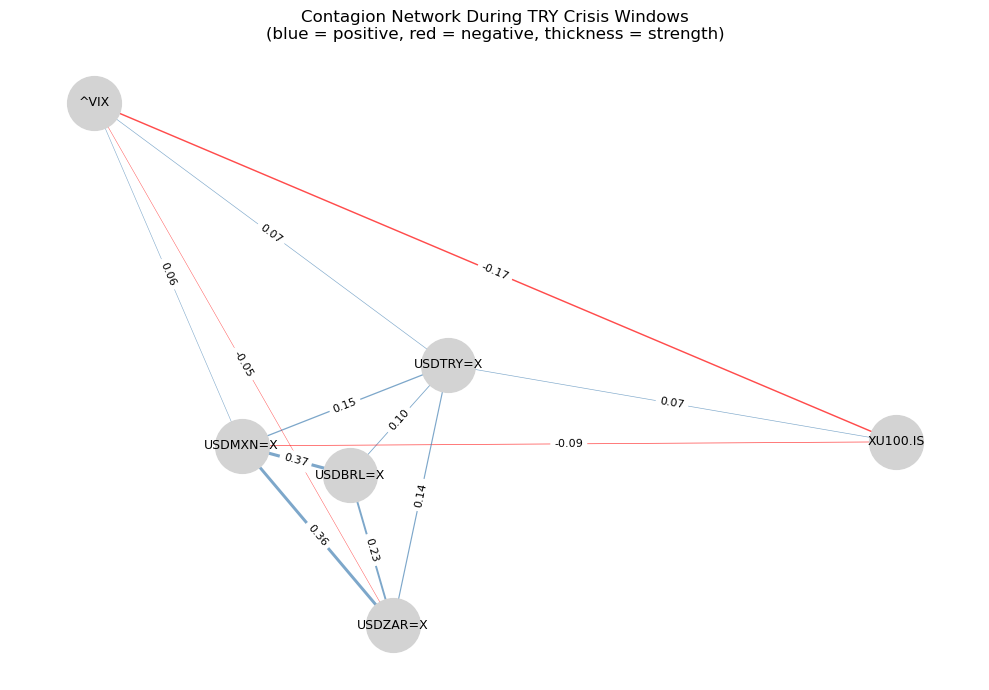

In [35]:
import networkx as nx

# use crisis period correlation matrix as edge weights
corr_matrix = crisis_corr.copy()

# build the graph
G = nx.Graph()
assets = corr_matrix.columns.tolist()

for i, a1 in enumerate(assets):
    for j, a2 in enumerate(assets):
        if i < j:
            weight = corr_matrix.loc[a1, a2]
            if abs(weight) > 0.05:  # filter near-zero edges for clarity
                G.add_edge(a1, a2, weight=weight)

# draw
pos = nx.spring_layout(G, seed=42)
edges = G.edges(data=True)
weights = [d["weight"] for _, _, d in edges]
colors = ["red" if w < 0 else "steelblue" for w in weights]
widths = [abs(w) * 6 for w in weights]  # scale thickness by strength

plt.figure(figsize=(10, 7))
nx.draw_networkx_nodes(G, pos, node_size=1500, node_color="lightgrey")
nx.draw_networkx_labels(G, pos, font_size=9)
nx.draw_networkx_edges(G, pos, width=widths, edge_color=colors, alpha=0.7)
edge_labels = {(u, v): f"{d['weight']:.2f}" for u, v, d in edges}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)
plt.title("Contagion Network During TRY Crisis Windows\n(blue = positive, red = negative, thickness = strength)")
plt.axis("off")
plt.tight_layout()
plt.show()

The network tells a clear story with three parts.

The EM currency cluster — BRL, MXN, and ZAR are all positively connected to each other, with ZAR sitting at the centre of that cluster with the thickest blue edges. These three currencies move together during TRY crisis windows, but this is largely their own internal co-movement rather than a direct TRY transmission story.

TRY's position — USDTRY sits somewhat isolated. Its connections to the EM currencies are thin, meaning weak co-movement. It has the strongest link to MXN and ZAR among the three, but none of them are thick enough to suggest powerful direct contagion.

VIX and BIST tell the most interesting story — the thickest red line in the diagram is VIX to XU100.IS at -0.17, meaning when volatility expectations rise, Turkish equities fall. That is the dominant relationship for BIST, not TRY itself. VIX also has a negative relationship with MXN, reinforcing the point from earlier that MXN's behaviour during crisis windows is more about global risk sentiment than Turkey-specific contagion.

The overall picture is that during TRY crisis windows, the EM currencies mostly co-move with each other, BIST responds more to global volatility than to TRY directly, and TRY itself sits on the periphery of the network rather than at its centre. That is not the contagion story you might have expected going in, but it is an honest and interesting one.